In [1]:
import sys
sys.path.append('/home/james/ml-proj/predmain/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import matthews_corrcoef, make_scorer

from features import engineer_features, get_feature_columns, get_target_column
from evaluate import plot_confusion_matrix

sns.set_theme(style='darkgrid')

MODEL_PATH = '/home/james/ml-proj/predmain/outputs/models/xgb_model.pkl'

# Load saved model + threshold (saved as dict by pipeline.py)
saved     = joblib.load(MODEL_PATH)
model     = saved['model']
THRESHOLD = float(saved['threshold'])

# Recreate the exact same split as pipeline.py
df = pd.read_csv('/home/james/ml-proj/predmain/data/ai4i2020.csv')
df = df.drop(columns=['UDI', 'Product ID'], errors='ignore')
df = engineer_features(df)

X = df[get_feature_columns()]
y = df[get_target_column()]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f'Features:  {get_feature_columns()}')
print(f'Threshold: {THRESHOLD}  (auto-selected on validation set, ≥85% recall constraint)')
print(f'Split:     train {len(X_train)} / val {len(X_val)} / test {len(X_test)}')


Dropped 19 RNF rows (10000 → 9981)
Features:  ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min', 'power_W', 'temp_delta_K', 'torque_wear', 'product_type']
Threshold: 0.31  (auto-selected on validation set, ≥85% recall constraint)
Split:     train 6986 / val 1497 / test 1498


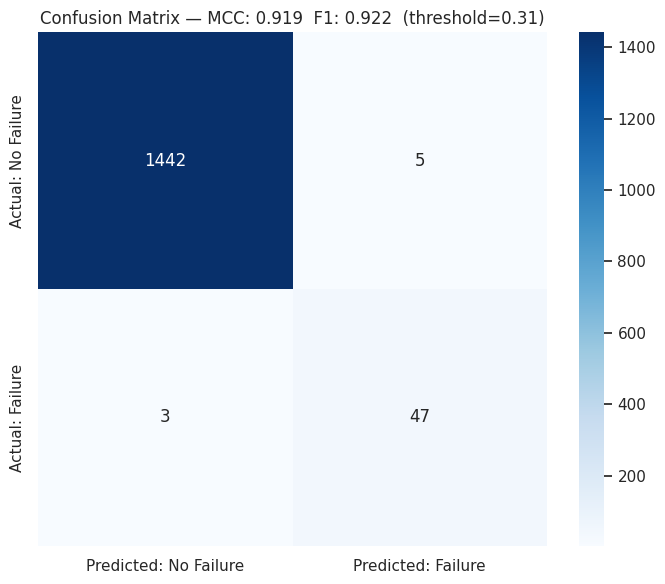

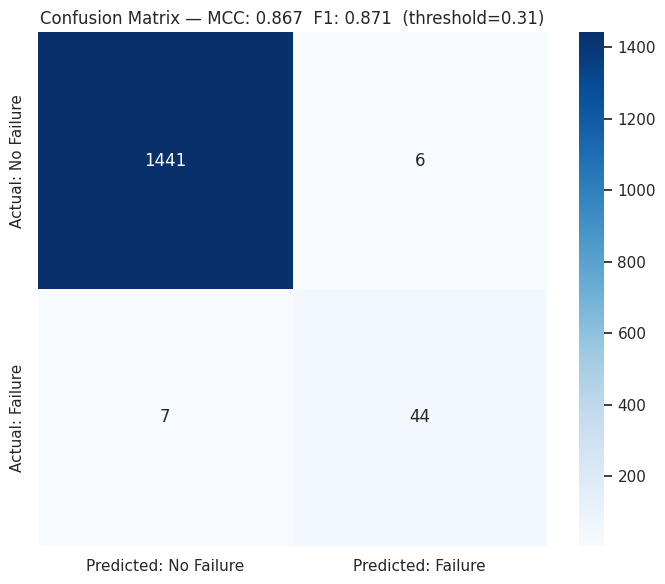

       Set   MCC    F1  Recall  Precision
Validation 0.919 0.922   0.940      0.904
      Test 0.867 0.871   0.863      0.880
   Overall 0.893 0.896   0.901      0.892

Val↔Test MCC gap: 0.052  (✓ OK — gap < 0.10)


In [2]:
# Q: How does the model perform on validation and test sets?
val_m  = plot_confusion_matrix(model, X_val,  y_val,  threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_val.png')
test_m = plot_confusion_matrix(model, X_test, y_test, threshold=THRESHOLD,
    save_path='/home/james/ml-proj/predmain/outputs/figures/confusion_matrix_test.png')

# Overall summary — the user cares about mean across val + test
results = pd.DataFrame([
    {'Set': 'Validation', 'MCC': round(val_m['mcc'], 3),  'F1': round(val_m['f1'], 3),
     'Recall': round(val_m['recall'], 3), 'Precision': round(val_m['precision'], 3)},
    {'Set': 'Test',       'MCC': round(test_m['mcc'], 3), 'F1': round(test_m['f1'], 3),
     'Recall': round(test_m['recall'], 3), 'Precision': round(test_m['precision'], 3)},
    {'Set': 'Overall',
     'MCC': round((val_m['mcc'] + test_m['mcc']) / 2, 3),
     'F1':  round((val_m['f1']  + test_m['f1'])  / 2, 3),
     'Recall': round((val_m['recall'] + test_m['recall']) / 2, 3),
     'Precision': round((val_m['precision'] + test_m['precision']) / 2, 3)},
])
print(results.to_string(index=False))

gap = abs(test_m['mcc'] - val_m['mcc'])
print(f'\nVal↔Test MCC gap: {gap:.3f}  ({"⚠ overfit concern" if gap > 0.10 else "✓ OK — gap < 0.10"})')


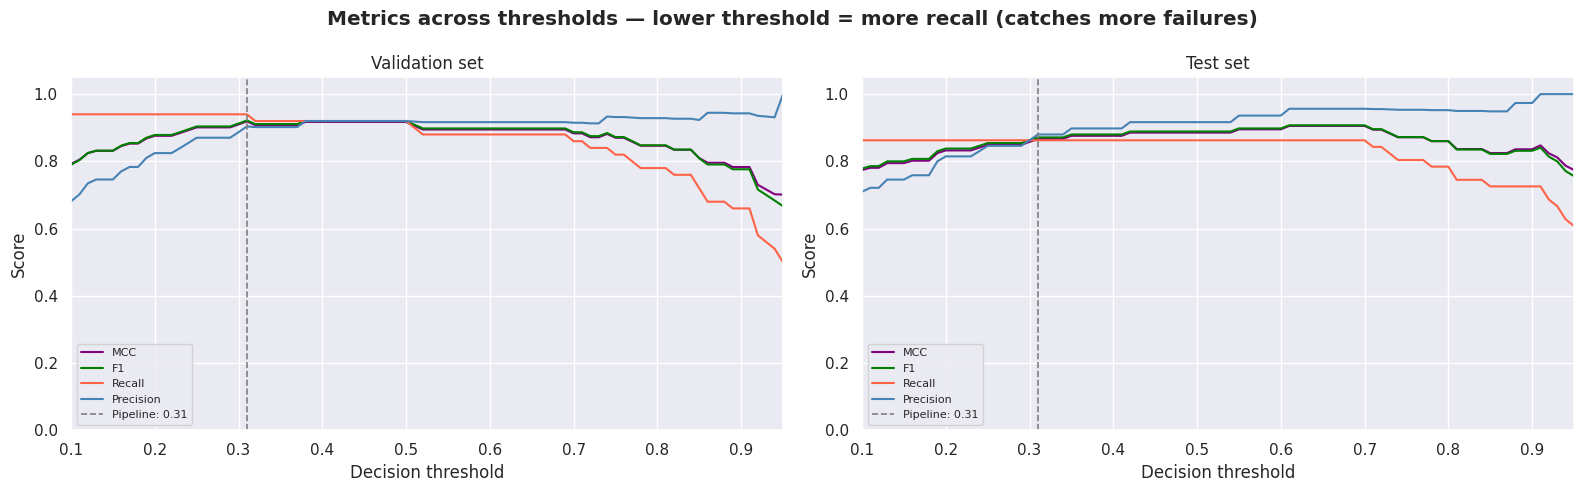

 Threshold  Val MCC  Test MCC  Val Recall  Test Recall  Val F1  Test F1       Note
      0.30    0.910     0.858        0.94        0.863   0.913    0.863           
      0.31    0.919     0.867        0.94        0.863   0.922    0.871 ← selected
      0.50    0.917     0.886        0.92        0.863   0.920    0.889           
      0.70    0.883     0.905        0.86        0.863   0.887    0.907           
      0.90    0.783     0.836        0.66        0.725   0.776    0.831           


In [3]:
# Q: What threshold gives the best balance across val AND test?
# In predictive maintenance, recall is paramount — missing a failure is far
# worse than a false alarm.  We show metrics across thresholds on both sets
# so you can see exactly how the pipeline's threshold performs.
from sklearn.metrics import f1_score, recall_score, precision_score

sweep_t = np.arange(0.10, 0.96, 0.01)

def metrics_at_thresholds(y_true, y_proba, thresholds):
    rows = []
    for t in thresholds:
        yp = (y_proba >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'mcc':       float(matthews_corrcoef(y_true, yp)),
            'f1':        float(f1_score(y_true, yp, zero_division=0)),
            'recall':    float(recall_score(y_true, yp, zero_division=0)),
            'precision': float(precision_score(y_true, yp, zero_division=0)),
        })
    return pd.DataFrame(rows)

val_proba  = model.predict_proba(X_val)[:, 1]
test_proba = model.predict_proba(X_test)[:, 1]

val_df  = metrics_at_thresholds(y_val,  val_proba,  sweep_t)
test_df = metrics_at_thresholds(y_test, test_proba, sweep_t)

# Two-panel plot: val and test
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, df_plot, title in [(axes[0], val_df, 'Validation'), (axes[1], test_df, 'Test')]:
    ax.plot(df_plot.threshold, df_plot.mcc,       color='purple',    lw=1.5, label='MCC')
    ax.plot(df_plot.threshold, df_plot.f1,        color='green',     lw=1.5, label='F1')
    ax.plot(df_plot.threshold, df_plot.recall,    color='tomato',    lw=1.5, label='Recall')
    ax.plot(df_plot.threshold, df_plot.precision, color='steelblue', lw=1.5, label='Precision')
    ax.axvline(THRESHOLD, color='gray', ls='--', lw=1.2, label=f'Pipeline: {THRESHOLD}')
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'{title} set')
    ax.legend(fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0.10, 0.95)

plt.suptitle('Metrics across thresholds — lower threshold = more recall (catches more failures)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/threshold_curve.png', dpi=150)
plt.show()

# Summary table at key thresholds (val + test side by side)
key_t = sorted({0.3, 0.5, THRESHOLD, 0.7, 0.9})
rows = []
for t in key_t:
    v = val_df[val_df.threshold == t]
    te = test_df[test_df.threshold == t]
    if v.empty or te.empty:
        continue
    v, te = v.iloc[0], te.iloc[0]
    rows.append({
        'Threshold': t,
        'Val MCC': round(v.mcc, 3),   'Test MCC': round(te.mcc, 3),
        'Val Recall': round(v.recall, 3), 'Test Recall': round(te.recall, 3),
        'Val F1': round(v.f1, 3),     'Test F1': round(te.f1, 3),
        'Note': '← selected' if t == THRESHOLD else '',
    })
print(pd.DataFrame(rows).to_string(index=False))


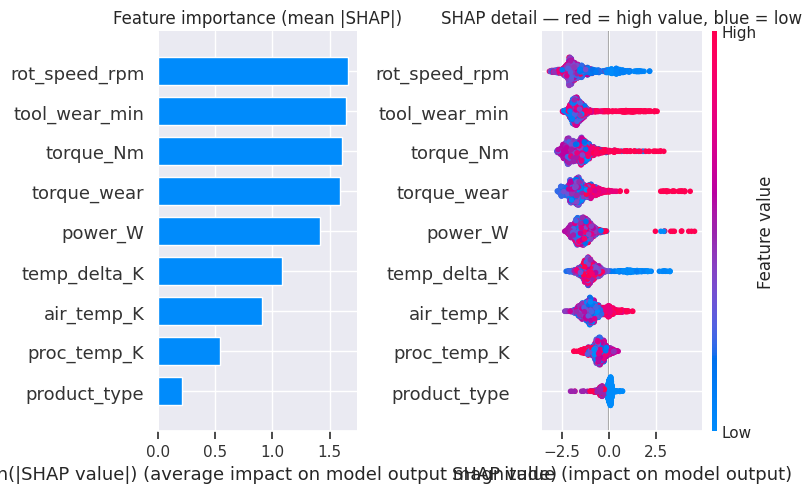

In [4]:
# Q: Which features does the model actually rely on?
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

plt.sca(axes[0])
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
axes[0].set_title('Feature importance (mean |SHAP|)')

plt.sca(axes[1])
shap.summary_plot(shap_values, X_test, show=False)
axes[1].set_title('SHAP detail — red = high value, blue = low')

plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/shap.png', dpi=150, bbox_inches='tight')
plt.show()


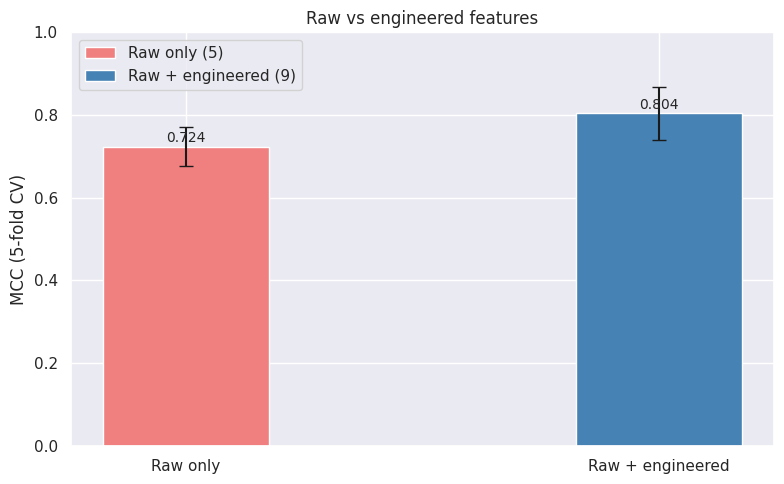

         Feature set  Mean MCC   Std Improvement
        Raw only (5)     0.724 0.047            
Raw + engineered (9)     0.804 0.064     +0.0803


In [5]:
# Q: Did engineered features improve on raw-only?
from models import build_model, get_class_weight

raw_cols = ['air_temp_K', 'proc_temp_K', 'rot_speed_rpm', 'torque_Nm', 'tool_wear_min']
all_cols = get_feature_columns()

skf        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
mcc_scorer = make_scorer(matthews_corrcoef)
weight     = get_class_weight(y)

mcc_raw = cross_val_score(build_model(scale_pos_weight=weight), X[raw_cols], y, cv=skf, scoring=mcc_scorer)
mcc_eng = cross_val_score(build_model(scale_pos_weight=weight), X[all_cols], y, cv=skf, scoring=mcc_scorer)

fig, ax = plt.subplots(figsize=(8, 5))
x, w = np.arange(2), 0.35
b1 = ax.bar(x[0], mcc_raw.mean(), w, yerr=mcc_raw.std(), capsize=5,
            color='lightcoral', label=f'Raw only ({len(raw_cols)})')
b2 = ax.bar(x[1], mcc_eng.mean(), w, yerr=mcc_eng.std(), capsize=5,
            color='steelblue', label=f'Raw + engineered ({len(all_cols)})')
ax.set_xticks(x)
ax.set_xticklabels(['Raw only', 'Raw + engineered'])
ax.set_ylabel('MCC (5-fold CV)')
ax.set_ylim(0, 1)
ax.set_title('Raw vs engineered features')
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', fontsize=10)
ax.legend()
plt.tight_layout()
plt.savefig('/home/james/ml-proj/predmain/outputs/figures/raw_vs_engineered.png', dpi=150)
plt.show()

# Summary table
print(pd.DataFrame({
    'Feature set':   ['Raw only (5)', 'Raw + engineered (9)'],
    'Mean MCC':      [round(mcc_raw.mean(), 3), round(mcc_eng.mean(), 3)],
    'Std':           [round(mcc_raw.std(), 3), round(mcc_eng.std(), 3)],
    'Improvement':   ['', f'+{mcc_eng.mean() - mcc_raw.mean():.4f}'],
}).to_string(index=False))
